
# Election Bloc Change Prediction Project  
## Notebook 06 — Unseen Localities, Shrinkage and Hybrid Routing

### Purpose

Notebook 05 found that the best learned delta model did not improve the primary unweighted MAE over previous-election persistence on the full comparable validation sample.

However, the results were heterogeneous:

- the learned model performed better in some population groups and blocs;
- persistence remained much stronger in others;
- the learned model improved weighted and median errors even when mean MAE was worse.

This notebook tests whether that apparent value is robust when entire localities are absent from model training.

### Main research questions

1. Does the selected Ridge architecture generalize to **unseen localities**?
2. Does shrinking the model correction toward persistence improve robustness?
3. Is a transparent hybrid rule justified?
   - learned model for non-Arab localities
   - persistence for Arab/non-Jewish localities
4. Can any strategy beat persistence consistently in both:
   - grouped unseen-locality cross-validation
   - temporal validation on K23→K24?

### Leakage and selection policy

- `K24_to_K25` remains locked and is not evaluated.
- Ridge architecture and alpha come from Notebook 05.
- Shrinkage values are selected using **training-transition grouped out-of-fold predictions only**.
- The hybrid routing rule is considered eligible only when the training-only OOF results support its direction.
- The final candidate is frozen before the final-test notebook.
- Development-period grouped CV is a robustness diagnostic, not a replacement for the untouched final test.

### Candidate strategies

1. `Previous-election persistence`
2. `Ridge — raw correction`
3. `Ridge — globally shrunk correction`
4. `Hybrid — Ridge for Non-Arab, persistence for Arab`
5. `Hybrid — shrunk Ridge for Non-Arab, persistence for Arab`

### Main outputs

- `reports/tables/training_oof_shrinkage_selection.csv`
- `reports/tables/training_oof_strategy_comparison.csv`
- `reports/tables/unseen_locality_cv_comparison.csv`
- `reports/tables/unseen_locality_cv_by_group.csv`
- `reports/tables/unseen_locality_cv_by_bloc.csv`
- `reports/tables/temporal_validation_strategy_comparison.csv`
- `reports/tables/temporal_validation_by_group.csv`
- `reports/tables/temporal_validation_by_bloc.csv`
- `data/processed/unseen_locality_oof_predictions.csv`
- `data/processed/temporal_validation_hybrid_predictions.csv`
- `reports/summaries/final_candidate_before_test.json`
- `reports/summaries/notebook_06_summary.json`


## 1. Imports and repository setup

In [1]:

from pathlib import Path
import json
import os
import shutil
import subprocess
import sys
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 280)
pd.set_option("display.max_rows", 150)

RANDOM_STATE = 99

MODELED_BLOCS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
]

TRAIN_TRANSITIONS = [
    "K21_to_K22",
    "K22_to_K23",
]

VALIDATION_TRANSITION = "K23_to_K24"
FINAL_TEST_TRANSITION = "K24_to_K25"

TARGET_CLR_COLUMNS = [
    f"delta_clr_{bloc}"
    for bloc in MODELED_BLOCS
]

PREVIOUS_CLR_COLUMNS = [
    f"previous_clr_{bloc}"
    for bloc in MODELED_BLOCS
]

PREVIOUS_PCT_COLUMNS = [
    f"previous_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

CURRENT_PCT_COLUMNS = [
    f"current_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

CATEGORICAL_FEATURE = "locality_type"
TRAINING_MISSINGNESS_THRESHOLD = 0.30

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)


Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1


In [2]:

REPO_URL = (
    "https://github.com/IfatDav/"
    "Election_Bloc_Prediction_Project.git"
)

DEFAULT_REPO_DIR = Path(
    "/content/Election_Bloc_Prediction_Project"
)


def locate_repository():
    candidates = []

    explicit_root = os.getenv(
        "ELECTION_PROJECT_ROOT"
    )

    if explicit_root:
        candidates.append(
            Path(explicit_root).expanduser()
        )

    current = Path.cwd().resolve()

    candidates.extend([
        current,
        *current.parents,
        DEFAULT_REPO_DIR,
        Path(
            "/content/Election_Bloc_Change_Project"
        ),
    ])

    checked = set()

    for candidate in candidates:
        candidate = candidate.resolve()

        if candidate in checked:
            continue

        checked.add(candidate)

        if (
            candidate / "data" / "raw"
        ).exists():
            return candidate

    if Path("/content").exists():
        if DEFAULT_REPO_DIR.exists():
            shutil.rmtree(
                DEFAULT_REPO_DIR
            )

        print("Repository not found locally.")
        print("Cloning the project repository...")

        result = subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(DEFAULT_REPO_DIR),
            ],
            text=True,
            capture_output=True,
        )

        if result.stdout:
            print(result.stdout)

        if result.returncode != 0:
            if result.stderr:
                print(result.stderr)

            raise RuntimeError(
                "Git clone failed. Review the output above."
            )

        return DEFAULT_REPO_DIR

    checked_text = "\n".join(
        f"- {path}"
        for path in checked
    )

    raise FileNotFoundError(
        "Could not locate the project repository.\n"
        f"Checked:\n{checked_text}"
    )


def synchronize_if_missing(
    repo_root,
    required_paths,
):
    missing = [
        path
        for path in required_paths
        if not path.exists()
    ]

    if not missing:
        return

    if not (
        repo_root / ".git"
    ).exists():
        return

    print("Some required files are missing locally.")
    print("Synchronizing with GitHub...")

    result = subprocess.run(
        [
            "git",
            "-C",
            str(repo_root),
            "pull",
            "--ff-only",
            "origin",
            "main",
        ],
        text=True,
        capture_output=True,
    )

    if result.stdout:
        print(result.stdout)

    if result.returncode != 0:
        if result.stderr:
            print(result.stderr)

        raise RuntimeError(
            "Git pull failed. Restart the runtime or "
            "resolve local repository conflicts."
        )


REPO_ROOT = locate_repository()

INTERIM_DIR = REPO_ROOT / "data" / "interim"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
REPORTS_DIR = REPO_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
SUMMARIES_DIR = REPORTS_DIR / "summaries"
MODELS_DIR = REPO_ROOT / "models"

for directory in [
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
    MODELS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

MODELING_FEATURES_PATH = (
    INTERIM_DIR
    / "modeling_transition_features.csv"
)

FEATURE_MANIFEST_PATH = (
    SUMMARIES_DIR
    / "feature_manifest.json"
)

NOTEBOOK_05_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_05_summary.json"
)

SELECTED_MODEL_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "selected_delta_model.json"
)

BEST_MODEL_ARTIFACT_PATH = (
    MODELS_DIR
    / "best_learned_delta_model.joblib"
)

synchronize_if_missing(
    REPO_ROOT,
    [
        MODELING_FEATURES_PATH,
        FEATURE_MANIFEST_PATH,
        NOTEBOOK_05_SUMMARY_PATH,
        SELECTED_MODEL_SUMMARY_PATH,
        BEST_MODEL_ARTIFACT_PATH,
    ],
)

print("Repository root:", REPO_ROOT)
print("Modeling data:", MODELING_FEATURES_PATH)
print("Notebook 05 model:", BEST_MODEL_ARTIFACT_PATH)


Repository not found locally.
Cloning the project repository...
Repository root: /content/Election_Bloc_Prediction_Project
Modeling data: /content/Election_Bloc_Prediction_Project/data/interim/modeling_transition_features.csv
Notebook 05 model: /content/Election_Bloc_Prediction_Project/models/best_learned_delta_model.joblib


## 2. Load and validate Notebook 05 outputs

In [3]:

required_paths = [
    MODELING_FEATURES_PATH,
    FEATURE_MANIFEST_PATH,
    NOTEBOOK_05_SUMMARY_PATH,
    SELECTED_MODEL_SUMMARY_PATH,
    BEST_MODEL_ARTIFACT_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Required Notebook 05 outputs are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )

modeling_data = pd.read_csv(
    MODELING_FEATURES_PATH,
    dtype={
        "locality_symbol": "string",
    },
    low_memory=False,
)

with FEATURE_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:
    feature_manifest = json.load(file)

with NOTEBOOK_05_SUMMARY_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:
    notebook_05_summary = json.load(file)

with SELECTED_MODEL_SUMMARY_PATH.open(
    "r",
    encoding="utf-8-sig",
) as file:
    selected_model_summary = json.load(file)

selected_model_artifact = joblib.load(
    BEST_MODEL_ARTIFACT_PATH
)

selected_pipeline = selected_model_artifact[
    "pipeline"
]

selected_alpha = float(
    selected_pipeline.named_steps[
        "model"
    ].alpha
)

selected_model_name = (
    selected_model_artifact[
        "model_name"
    ]
)

if (
    selected_model_name
    != "Ridge — history + levels"
):
    raise ValueError(
        "Notebook 06 expects the selected Notebook 05 "
        "architecture to be Ridge — history + levels. "
        f"Found: {selected_model_name}"
    )

expected_rows = int(
    notebook_05_summary[
        "analysis_sample"
    ]["coverage"][0][
        "full_rows"
    ]
    + notebook_05_summary[
        "analysis_sample"
    ]["coverage"][1][
        "full_rows"
    ]
    + notebook_05_summary[
        "analysis_sample"
    ]["coverage"][2][
        "full_rows"
    ]
)

if len(modeling_data) != expected_rows:
    raise ValueError(
        "Modeling row count differs from Notebook 05 metadata. "
        f"Expected {expected_rows}, found {len(modeling_data)}."
    )

duplicate_count = int(
    modeling_data.duplicated(
        [
            "locality_symbol",
            "transition_id",
        ]
    ).sum()
)

if duplicate_count:
    raise ValueError(
        f"Found {duplicate_count} duplicated locality-transition rows."
    )

print("Selected architecture:", selected_model_name)
print("Fixed Ridge alpha:", selected_alpha)
print(
    "Notebook 05 operational recommendation:",
    selected_model_summary[
        "operational_recommendation"
    ],
)


Selected architecture: Ridge — history + levels
Fixed Ridge alpha: 1000.0
Notebook 05 operational recommendation: Previous-election persistence


## 3. Prepare the development sample and lock the final test

In [4]:

def coerce_boolean(series):
    if pd.api.types.is_bool_dtype(
        series
    ):
        return series.fillna(False)

    normalized = (
        series.astype("string")
        .str.strip()
        .str.lower()
    )

    return normalized.isin([
        "true",
        "1",
        "yes",
        "y",
    ])


modeling_data[
    "has_complete_annual_pair"
] = coerce_boolean(
    modeling_data[
        "has_complete_annual_pair"
    ]
)

modeling_data[
    "previous_log_valid_votes"
] = np.log1p(
    pd.to_numeric(
        modeling_data[
            "previous_valid_votes"
        ],
        errors="coerce",
    )
)

train_full = modeling_data.loc[
    modeling_data[
        "transition_id"
    ].isin(
        TRAIN_TRANSITIONS
    )
].copy()

validation_full = modeling_data.loc[
    modeling_data[
        "transition_id"
    ].eq(
        VALIDATION_TRANSITION
    )
].copy()

final_test_locked = modeling_data.loc[
    modeling_data[
        "transition_id"
    ].eq(
        FINAL_TEST_TRANSITION
    )
].copy()

train_data = train_full.loc[
    train_full[
        "has_complete_annual_pair"
    ]
].copy()

validation_data = validation_full.loc[
    validation_full[
        "has_complete_annual_pair"
    ]
].copy()

development_data = pd.concat(
    [
        train_data,
        validation_data,
    ],
    ignore_index=True,
)

if final_test_locked.empty:
    raise ValueError(
        "The locked final-test transition is missing."
    )

print("Training rows:", len(train_data))
print("Validation rows:", len(validation_data))
print("Development rows:", len(development_data))
print(
    "Development unique localities:",
    development_data[
        "locality_symbol"
    ].nunique(),
)
print(
    "Locked final-test rows:",
    len(final_test_locked),
)


Training rows: 449
Validation rows: 224
Development rows: 673
Development unique localities: 225
Locked final-test rows: 1213



The final-test rows are loaded only to verify that the locked transition exists. No final-test target is used below.


## 4. Reconstruct the selected model architecture

In [5]:

manifest_current_features = [
    column
    for column in feature_manifest[
        "current_annual_feature_columns"
    ]
    if column in modeling_data.columns
]

history_numeric_features = [
    *PREVIOUS_CLR_COLUMNS,
    "previous_turnout_pct",
    "previous_log_valid_votes",
]

RAW_SELECTED_FEATURES = [
    *history_numeric_features,
    CATEGORICAL_FEATURE,
    *manifest_current_features,
]

print(
    "Raw selected-architecture features:",
    len(RAW_SELECTED_FEATURES),
)


Raw selected-architecture features: 181


In [6]:

def filter_features_from_training(
    data,
    feature_columns,
):
    kept_features = []
    audit_rows = []

    for column in feature_columns:
        if column not in data.columns:
            audit_rows.append({
                "feature": column,
                "feature_type": "unknown",
                "training_missing_pct": np.nan,
                "training_unique_non_missing": 0,
                "kept": False,
                "reason": "column_missing",
            })
            continue

        if column == CATEGORICAL_FEATURE:
            values = (
                data[column]
                .astype("string")
            )

            missing_pct = float(
                values.isna().mean()
                * 100
            )

            unique_count = int(
                values.nunique(
                    dropna=True
                )
            )

            keep = unique_count > 1

            audit_rows.append({
                "feature": column,
                "feature_type": "categorical",
                "training_missing_pct": missing_pct,
                "training_unique_non_missing": (
                    unique_count
                ),
                "kept": keep,
                "reason": (
                    "kept"
                    if keep
                    else "constant_or_empty"
                ),
            })

            if keep:
                kept_features.append(
                    column
                )

            continue

        numeric_values = pd.to_numeric(
            data[column],
            errors="coerce",
        )

        missing_rate = float(
            numeric_values.isna().mean()
        )

        unique_count = int(
            numeric_values.nunique(
                dropna=True
            )
        )

        if missing_rate > (
            TRAINING_MISSINGNESS_THRESHOLD
        ):
            keep = False
            reason = (
                "missingness_above_threshold"
            )
        elif unique_count <= 1:
            keep = False
            reason = "constant_or_empty"
        else:
            keep = True
            reason = "kept"

        audit_rows.append({
            "feature": column,
            "feature_type": "numeric",
            "training_missing_pct": (
                missing_rate * 100
            ),
            "training_unique_non_missing": (
                unique_count
            ),
            "kept": keep,
            "reason": reason,
        })

        if keep:
            kept_features.append(
                column
            )

    if not kept_features:
        raise ValueError(
            "No model features survived training-only filtering."
        )

    return (
        kept_features,
        pd.DataFrame(
            audit_rows
        ),
    )


def make_one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def prepare_feature_frame(
    data,
    feature_columns,
):
    output = data[
        feature_columns
    ].copy()

    for column in feature_columns:
        if column == CATEGORICAL_FEATURE:
            output[column] = (
                output[column]
                .astype("string")
                .fillna("Unknown")
                .astype(str)
            )
        else:
            output[column] = pd.to_numeric(
                output[column],
                errors="coerce",
            ).astype("float64")

    return output


def build_ridge_pipeline(
    feature_columns,
    alpha,
):
    categorical_columns = [
        column
        for column in feature_columns
        if column == CATEGORICAL_FEATURE
    ]

    numeric_columns = [
        column
        for column in feature_columns
        if column
        not in categorical_columns
    ]

    transformers = []

    if numeric_columns:
        transformers.append(
            (
                "numeric",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="median",
                            add_indicator=True,
                        ),
                    ),
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                ]),
                numeric_columns,
            )
        )

    if categorical_columns:
        transformers.append(
            (
                "categorical",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy=(
                                "most_frequent"
                            )
                        ),
                    ),
                    (
                        "one_hot",
                        make_one_hot_encoder(),
                    ),
                ]),
                categorical_columns,
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
    )

    return Pipeline([
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            Ridge(
                alpha=alpha,
            ),
        ),
    ])


## 5. Prediction and evaluation utilities

In [7]:

def center_clr_rows(values):
    values = np.asarray(
        values,
        dtype=float,
    )

    return (
        values
        - values.mean(
            axis=1,
            keepdims=True,
        )
    )


def inverse_clr(clr_values):
    clr_values = np.asarray(
        clr_values,
        dtype=float,
    )

    shifted = (
        clr_values
        - clr_values.max(
            axis=1,
            keepdims=True,
        )
    )

    exp_values = np.exp(
        shifted
    )

    return (
        exp_values
        / exp_values.sum(
            axis=1,
            keepdims=True,
        )
        * 100
    )


def delta_clr_to_composition(
    data,
    predicted_delta_clr,
):
    centered_delta = center_clr_rows(
        predicted_delta_clr
    )

    previous_clr = data[
        PREVIOUS_CLR_COLUMNS
    ].to_numpy(dtype=float)

    return inverse_clr(
        previous_clr
        + centered_delta
    )


def predict_delta_clr(
    pipeline,
    data,
    feature_columns,
):
    features = prepare_feature_frame(
        data,
        feature_columns,
    )

    predicted_delta = pipeline.predict(
        features
    )

    return center_clr_rows(
        predicted_delta
    )


def safe_r2(
    y_true,
    y_pred,
):
    if len(y_true) < 2:
        return np.nan

    if np.nanstd(y_true) == 0:
        return np.nan

    return float(
        r2_score(
            y_true,
            y_pred,
        )
    )


def evaluate_composition(
    data,
    predictions,
    strategy_name,
):
    y_true = data[
        CURRENT_PCT_COLUMNS
    ].to_numpy(dtype=float)

    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    if predictions.shape != y_true.shape:
        raise ValueError(
            f"{strategy_name}: prediction shape "
            f"{predictions.shape} does not match "
            f"target shape {y_true.shape}."
        )

    sum_error = float(
        np.abs(
            predictions.sum(axis=1)
            - 100
        ).max()
    )

    if sum_error > 1e-6:
        raise ValueError(
            f"{strategy_name}: predicted compositions "
            "do not sum to 100."
        )

    absolute_errors = np.abs(
        y_true
        - predictions
    )

    row_mae = absolute_errors.mean(
        axis=1
    )

    weights = pd.to_numeric(
        data[
            "current_valid_votes"
        ],
        errors="coerce",
    ).to_numpy(dtype=float)

    weighted_mae = float(
        np.average(
            row_mae,
            weights=weights,
        )
    )

    r2_values = [
        safe_r2(
            y_true[:, index],
            predictions[:, index],
        )
        for index in range(
            len(MODELED_BLOCS)
        )
    ]

    finite_r2 = [
        value
        for value in r2_values
        if np.isfinite(value)
    ]

    macro_r2 = (
        float(
            np.mean(finite_r2)
        )
        if finite_r2
        else np.nan
    )

    overall = {
        "strategy": strategy_name,
        "rows": len(data),
        "mae": float(
            absolute_errors.mean()
        ),
        "median_row_mae": float(
            np.median(row_mae)
        ),
        "weighted_mae": weighted_mae,
        "macro_r2": macro_r2,
        "maximum_prediction_sum_error": (
            sum_error
        ),
    }

    by_bloc = []

    for index, bloc in enumerate(
        MODELED_BLOCS
    ):
        by_bloc.append({
            "strategy": strategy_name,
            "bloc": bloc,
            "rows": len(data),
            "mae": float(
                absolute_errors[
                    :,
                    index,
                ].mean()
            ),
            "median_absolute_error": float(
                np.median(
                    absolute_errors[
                        :,
                        index,
                    ]
                )
            ),
            "r2": r2_values[
                index
            ],
        })

    return (
        overall,
        by_bloc,
    )


def evaluate_by_group(
    data,
    predictions,
    strategy_name,
):
    rows = []

    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    group_series = (
        data[
            "analysis_group"
        ]
        .fillna("Unknown")
    )

    for group_value in sorted(
        group_series.unique().tolist()
    ):
        mask = (
            group_series
            .eq(group_value)
            .to_numpy()
        )

        group_data = data.loc[
            mask
        ]

        group_predictions = (
            predictions[mask]
        )

        overall, _ = (
            evaluate_composition(
                group_data,
                group_predictions,
                strategy_name,
            )
        )

        rows.append({
            "strategy": strategy_name,
            "analysis_group": (
                group_value
            ),
            **{
                key: value
                for key, value
                in overall.items()
                if key != "strategy"
            },
        })

    return rows


def build_strategy_predictions(
    data,
    raw_predicted_delta_clr,
    global_lambda,
    non_arab_lambda,
):
    raw_predicted_delta_clr = (
        center_clr_rows(
            raw_predicted_delta_clr
        )
    )

    persistence = data[
        PREVIOUS_PCT_COLUMNS
    ].to_numpy(dtype=float)

    raw_ridge = (
        delta_clr_to_composition(
            data,
            raw_predicted_delta_clr,
        )
    )

    shrunk_ridge = (
        delta_clr_to_composition(
            data,
            raw_predicted_delta_clr
            * global_lambda,
        )
    )

    non_arab_shrunk = (
        delta_clr_to_composition(
            data,
            raw_predicted_delta_clr
            * non_arab_lambda,
        )
    )

    is_non_arab = (
        data[
            "analysis_group"
        ]
        .fillna("Unknown")
        .eq("Non-Arab")
        .to_numpy()
    )

    hybrid_raw = persistence.copy()
    hybrid_raw[
        is_non_arab
    ] = raw_ridge[
        is_non_arab
    ]

    hybrid_shrunk = persistence.copy()
    hybrid_shrunk[
        is_non_arab
    ] = non_arab_shrunk[
        is_non_arab
    ]

    return {
        "Previous-election persistence": (
            persistence
        ),
        "Ridge — raw correction": (
            raw_ridge
        ),
        (
            "Ridge — globally shrunk correction"
        ): shrunk_ridge,
        (
            "Hybrid — Ridge Non-Arab / "
            "persistence Arab"
        ): hybrid_raw,
        (
            "Hybrid — shrunk Ridge Non-Arab / "
            "persistence Arab"
        ): hybrid_shrunk,
    }



## 6. Training-only grouped OOF predictions

These predictions use only the two training transitions.

For every fold, all records belonging to a locality are kept together. Feature filtering, imputation and scaling are refitted inside each fold.


In [8]:

def grouped_oof_delta_predictions(
    data,
    raw_feature_columns,
    alpha,
    n_splits=5,
):
    unique_groups = int(
        data[
            "locality_symbol"
        ].nunique()
    )

    n_splits = min(
        n_splits,
        unique_groups,
    )

    if n_splits < 2:
        raise ValueError(
            "At least two locality groups are required."
        )

    groups = (
        data[
            "locality_symbol"
        ]
        .astype(str)
        .to_numpy()
    )

    splitter = GroupKFold(
        n_splits=n_splits
    )

    oof_delta = np.full(
        (
            len(data),
            len(MODELED_BLOCS),
        ),
        np.nan,
        dtype=float,
    )

    fold_assignments = np.full(
        len(data),
        -1,
        dtype=int,
    )

    fold_audits = []

    for fold_number, (
        train_indices,
        test_indices,
    ) in enumerate(
        splitter.split(
            data,
            groups=groups,
        ),
        start=1,
    ):
        fold_train = data.iloc[
            train_indices
        ]

        fold_test = data.iloc[
            test_indices
        ]

        (
            fold_features,
            fold_feature_audit,
        ) = filter_features_from_training(
            fold_train,
            raw_feature_columns,
        )

        pipeline = build_ridge_pipeline(
            fold_features,
            alpha,
        )

        X_train = prepare_feature_frame(
            fold_train,
            fold_features,
        )

        y_train = fold_train[
            TARGET_CLR_COLUMNS
        ].to_numpy(dtype=float)

        pipeline.fit(
            X_train,
            y_train,
        )

        fold_delta = predict_delta_clr(
            pipeline,
            fold_test,
            fold_features,
        )

        oof_delta[
            test_indices
        ] = fold_delta

        fold_assignments[
            test_indices
        ] = fold_number

        train_localities = set(
            fold_train[
                "locality_symbol"
            ].astype(str)
        )

        test_localities = set(
            fold_test[
                "locality_symbol"
            ].astype(str)
        )

        overlap = (
            train_localities
            & test_localities
        )

        if overlap:
            raise ValueError(
                "Locality leakage detected in grouped CV."
            )

        fold_audits.append({
            "fold": fold_number,
            "train_rows": len(
                fold_train
            ),
            "test_rows": len(
                fold_test
            ),
            "train_localities": len(
                train_localities
            ),
            "test_localities": len(
                test_localities
            ),
            "locality_overlap": len(
                overlap
            ),
            "kept_features": len(
                fold_features
            ),
            "removed_features": int(
                (~fold_feature_audit[
                    "kept"
                ]).sum()
            ),
        })

    if np.isnan(
        oof_delta
    ).any():
        raise ValueError(
            "Some grouped OOF predictions were not created."
        )

    return (
        oof_delta,
        fold_assignments,
        pd.DataFrame(
            fold_audits
        ),
    )


(
    training_oof_delta,
    training_oof_folds,
    training_oof_fold_audit,
) = grouped_oof_delta_predictions(
    train_data.reset_index(
        drop=True
    ),
    RAW_SELECTED_FEATURES,
    selected_alpha,
    n_splits=5,
)

print(
    "Training OOF prediction rows:",
    len(training_oof_delta),
)
training_oof_fold_audit


Training OOF prediction rows: 449


,fold,train_rows,test_rows,train_localities,test_localities,locality_overlap,kept_features,removed_features
0,1,359,90,180,45,0,125,56
1,2,359,90,180,45,0,125,56
2,3,359,90,180,45,0,125,56
3,4,359,90,180,45,0,125,56
4,5,360,89,180,45,0,125,56


## 7. Select shrinkage using training OOF only

In [9]:

SHRINKAGE_GRID = np.round(
    np.linspace(
        0.0,
        1.0,
        21,
    ),
    2,
).tolist()

training_oof_data = (
    train_data.reset_index(
        drop=True
    )
)

shrinkage_rows = []

for lambda_value in SHRINKAGE_GRID:
    lambda_predictions = (
        delta_clr_to_composition(
            training_oof_data,
            training_oof_delta
            * lambda_value,
        )
    )

    overall_metrics, _ = (
        evaluate_composition(
            training_oof_data,
            lambda_predictions,
            f"lambda={lambda_value}",
        )
    )

    shrinkage_rows.append({
        "scope": "All localities",
        "lambda": lambda_value,
        "rows": len(
            training_oof_data
        ),
        "mae": overall_metrics[
            "mae"
        ],
        "weighted_mae": (
            overall_metrics[
                "weighted_mae"
            ]
        ),
        "median_row_mae": (
            overall_metrics[
                "median_row_mae"
            ]
        ),
    })

    non_arab_mask = (
        training_oof_data[
            "analysis_group"
        ]
        .fillna("Unknown")
        .eq("Non-Arab")
        .to_numpy()
    )

    non_arab_metrics, _ = (
        evaluate_composition(
            training_oof_data.loc[
                non_arab_mask
            ],
            lambda_predictions[
                non_arab_mask
            ],
            f"lambda={lambda_value}",
        )
    )

    shrinkage_rows.append({
        "scope": "Non-Arab",
        "lambda": lambda_value,
        "rows": int(
            non_arab_mask.sum()
        ),
        "mae": non_arab_metrics[
            "mae"
        ],
        "weighted_mae": (
            non_arab_metrics[
                "weighted_mae"
            ]
        ),
        "median_row_mae": (
            non_arab_metrics[
                "median_row_mae"
            ]
        ),
    })

training_oof_shrinkage_selection = (
    pd.DataFrame(
        shrinkage_rows
    )
)

best_global_lambda = float(
    training_oof_shrinkage_selection.loc[
        training_oof_shrinkage_selection[
            "scope"
        ].eq("All localities")
    ]
    .sort_values(
        [
            "mae",
            "lambda",
        ]
    )
    .iloc[0][
        "lambda"
    ]
)

best_non_arab_lambda = float(
    training_oof_shrinkage_selection.loc[
        training_oof_shrinkage_selection[
            "scope"
        ].eq("Non-Arab")
    ]
    .sort_values(
        [
            "mae",
            "lambda",
        ]
    )
    .iloc[0][
        "lambda"
    ]
)

print(
    "Selected global lambda:",
    best_global_lambda,
)
print(
    "Selected Non-Arab lambda:",
    best_non_arab_lambda,
)

training_oof_shrinkage_selection.loc[
    training_oof_shrinkage_selection[
        "scope"
    ].eq("All localities")
].sort_values("mae").head(10)


Selected global lambda: 0.9
Selected Non-Arab lambda: 0.9


,scope,lambda,rows,mae,weighted_mae,median_row_mae
36,All localities,0.90,449,1.839250,1.485863,1.170420
34,All localities,0.85,449,1.842615,1.481941,1.150649
38,All localities,0.95,449,1.845224,1.498334,1.157293
32,All localities,0.80,449,1.860364,1.494402,1.172648
40,All localities,1.00,449,1.860740,1.516979,1.145589
30,All localities,0.75,449,1.887268,1.513960,1.217600
28,All localities,0.70,449,1.921519,1.540538,1.271677
26,All localities,0.65,449,1.966575,1.573131,1.331419
24,All localities,0.60,449,2.018903,1.612198,1.371295
22,All localities,0.55,449,2.081455,1.663570,1.423887


## 8. Training-only support for hybrid routing

In [10]:

training_strategy_predictions = (
    build_strategy_predictions(
        training_oof_data,
        training_oof_delta,
        best_global_lambda,
        best_non_arab_lambda,
    )
)

training_overall_rows = []
training_group_rows = []
training_bloc_rows = []

for strategy_name, predictions in (
    training_strategy_predictions.items()
):
    overall, by_bloc = (
        evaluate_composition(
            training_oof_data,
            predictions,
            strategy_name,
        )
    )

    training_overall_rows.append(
        overall
    )

    training_bloc_rows.extend(
        by_bloc
    )

    training_group_rows.extend(
        evaluate_by_group(
            training_oof_data,
            predictions,
            strategy_name,
        )
    )

training_oof_strategy_comparison = (
    pd.DataFrame(
        training_overall_rows
    )
    .sort_values(
        [
            "mae",
            "weighted_mae",
        ]
    )
    .reset_index(drop=True)
)

training_oof_by_group = (
    pd.DataFrame(
        training_group_rows
    )
)

training_oof_by_bloc = (
    pd.DataFrame(
        training_bloc_rows
    )
)

def group_mae(
    table,
    strategy,
    group,
):
    result = table.loc[
        table[
            "strategy"
        ].eq(strategy)
        & table[
            "analysis_group"
        ].eq(group),
        "mae",
    ]

    if result.empty:
        return np.nan

    return float(
        result.iloc[0]
    )


training_non_arab_persistence_mae = (
    group_mae(
        training_oof_by_group,
        "Previous-election persistence",
        "Non-Arab",
    )
)

training_non_arab_ridge_mae = (
    group_mae(
        training_oof_by_group,
        "Ridge — raw correction",
        "Non-Arab",
    )
)

training_arab_persistence_mae = (
    group_mae(
        training_oof_by_group,
        "Previous-election persistence",
        "Arab/Non-Jewish",
    )
)

training_arab_ridge_mae = (
    group_mae(
        training_oof_by_group,
        "Ridge — raw correction",
        "Arab/Non-Jewish",
    )
)

hybrid_direction_supported = bool(
    np.isfinite(
        training_non_arab_persistence_mae
    )
    and np.isfinite(
        training_non_arab_ridge_mae
    )
    and np.isfinite(
        training_arab_persistence_mae
    )
    and np.isfinite(
        training_arab_ridge_mae
    )
    and (
        training_non_arab_ridge_mae
        < training_non_arab_persistence_mae
    )
    and (
        training_arab_persistence_mae
        <= training_arab_ridge_mae
    )
)

print(
    "Hybrid direction supported by training OOF:",
    hybrid_direction_supported,
)

training_oof_strategy_comparison


Hybrid direction supported by training OOF: False


,strategy,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error
0,Ridge — globally shrunk correction,449,1.839250,1.170420,1.485863,0.980316,2.842171e-14
1,Ridge — raw correction,449,1.860740,1.145589,1.516979,0.979101,2.842171e-14
2,Hybrid — shrunk Ridge Non-Arab / persistence Arab,449,2.579865,1.551221,1.728171,0.967766,2.842171e-14
3,Hybrid — Ridge Non-Arab / persistence Arab,449,2.594713,1.526629,1.760209,0.966915,2.842171e-14
4,Previous-election persistence,449,3.291335,2.492213,2.727155,0.960253,2.842171e-14


In [11]:

training_oof_by_group.sort_values(
    [
        "analysis_group",
        "mae",
    ]
)


,strategy,analysis_group,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error
4,Ridge — globally shrunk correction,Arab/Non-Jewish,162,2.730948,1.450261,1.949491,0.752150,2.842171e-14
2,Ridge — raw correction,Arab/Non-Jewish,162,2.749356,1.493673,1.942418,0.749652,2.842171e-14
0,Previous-election persistence,Arab/Non-Jewish,162,4.783639,3.438117,3.809019,0.665206,2.842171e-14
6,Hybrid — Ridge Non-Arab / persistence Arab,Arab/Non-Jewish,162,4.783639,3.438117,3.809019,0.665206,2.842171e-14
8,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Arab/Non-Jewish,162,4.783639,3.438117,3.809019,0.665206,2.842171e-14
5,Ridge — globally shrunk correction,Non-Arab,287,1.335922,1.019294,1.416397,0.976711,2.842171e-14
9,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Non-Arab,287,1.335922,1.019294,1.416397,0.976711,2.842171e-14
3,Ridge — raw correction,Non-Arab,287,1.359152,1.030760,1.453235,0.973363,2.842171e-14
7,Hybrid — Ridge Non-Arab / persistence Arab,Non-Arab,287,1.359152,1.030760,1.453235,0.973363,2.842171e-14
1,Previous-election persistence,Non-Arab,287,2.448990,2.236512,2.565059,0.957325,2.842171e-14



The hybrid strategies remain visible even when the training-only OOF result does not support the routing direction. In that case they are treated as exploratory and are not eligible to become the frozen final candidate.


## 9. Strict unseen-locality GroupKFold on the development period

In [12]:

development_data = (
    development_data.reset_index(
        drop=True
    )
)

(
    development_oof_delta,
    development_oof_folds,
    development_oof_fold_audit,
) = grouped_oof_delta_predictions(
    development_data,
    RAW_SELECTED_FEATURES,
    selected_alpha,
    n_splits=5,
)

development_strategy_predictions = (
    build_strategy_predictions(
        development_data,
        development_oof_delta,
        best_global_lambda,
        best_non_arab_lambda,
    )
)

unseen_overall_rows = []
unseen_group_rows = []
unseen_bloc_rows = []

for strategy_name, predictions in (
    development_strategy_predictions.items()
):
    overall, by_bloc = (
        evaluate_composition(
            development_data,
            predictions,
            strategy_name,
        )
    )

    unseen_overall_rows.append(
        overall
    )

    unseen_group_rows.extend(
        evaluate_by_group(
            development_data,
            predictions,
            strategy_name,
        )
    )

    unseen_bloc_rows.extend(
        by_bloc
    )

unseen_locality_cv_comparison = (
    pd.DataFrame(
        unseen_overall_rows
    )
    .sort_values(
        [
            "mae",
            "weighted_mae",
        ]
    )
    .reset_index(drop=True)
)

unseen_locality_cv_by_group = (
    pd.DataFrame(
        unseen_group_rows
    )
    .sort_values(
        [
            "analysis_group",
            "mae",
        ]
    )
    .reset_index(drop=True)
)

unseen_locality_cv_by_bloc = (
    pd.DataFrame(
        unseen_bloc_rows
    )
    .sort_values(
        [
            "bloc",
            "mae",
        ]
    )
    .reset_index(drop=True)
)

unseen_persistence_mae = float(
    unseen_locality_cv_comparison.loc[
        unseen_locality_cv_comparison[
            "strategy"
        ].eq(
            "Previous-election persistence"
        ),
        "mae",
    ].iloc[0]
)

unseen_locality_cv_comparison[
    "absolute_mae_improvement_vs_persistence"
] = (
    unseen_persistence_mae
    - unseen_locality_cv_comparison[
        "mae"
    ]
)

unseen_locality_cv_comparison[
    "relative_mae_improvement_vs_persistence_pct"
] = (
    unseen_locality_cv_comparison[
        "absolute_mae_improvement_vs_persistence"
    ]
    / unseen_persistence_mae
    * 100
)

unseen_locality_cv_comparison


,strategy,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error,absolute_mae_improvement_vs_persistence,relative_mae_improvement_vs_persistence_pct
0,Ridge — globally shrunk correction,673,2.151237,1.396040,1.721495,0.976437,2.842171e-14,1.127954,34.397328
1,Ridge — raw correction,673,2.173636,1.388287,1.781025,0.975711,2.842171e-14,1.105555,33.714254
2,Hybrid — shrunk Ridge Non-Arab / persistence Arab,673,2.623892,1.620770,1.860340,0.966383,2.842171e-14,0.655299,19.983547
3,Hybrid — Ridge Non-Arab / persistence Arab,673,2.668527,1.665994,1.926729,0.965418,2.842171e-14,0.610663,18.622384
4,Previous-election persistence,673,3.279190,2.495675,2.607586,0.959984,2.842171e-14,0.000000,0.000000


In [13]:

unseen_locality_cv_by_group


,strategy,analysis_group,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error
0,Ridge — raw correction,Arab/Non-Jewish,243,3.418066,2.328813,2.544394,0.768452,2.842171e-14
1,Ridge — globally shrunk correction,Arab/Non-Jewish,243,3.479649,2.455083,2.600858,0.770010,2.842171e-14
2,Previous-election persistence,Arab/Non-Jewish,243,4.788690,3.464907,3.743846,0.713647,2.842171e-14
3,Hybrid — Ridge Non-Arab / persistence Arab,Arab/Non-Jewish,243,4.788690,3.464907,3.743846,0.713647,2.842171e-14
4,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Arab/Non-Jewish,243,4.788690,3.464907,3.743846,0.713647,2.842171e-14
5,Ridge — globally shrunk correction,Non-Arab,430,1.400529,1.094285,1.599904,0.973633,2.842171e-14
6,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Non-Arab,430,1.400529,1.094285,1.599904,0.973633,2.842171e-14
7,Ridge — raw correction,Non-Arab,430,1.470388,1.127338,1.675473,0.971580,2.842171e-14
8,Hybrid — Ridge Non-Arab / persistence Arab,Non-Arab,430,1.470388,1.127338,1.675473,0.971580,2.842171e-14
9,Previous-election persistence,Non-Arab,430,2.426148,2.258791,2.450473,0.954258,2.842171e-14


In [14]:

unseen_locality_cv_by_bloc


,strategy,bloc,rows,mae,median_absolute_error,r2
0,Ridge — raw correction,Arab,673,1.841636,0.194666,0.990784
1,Ridge — globally shrunk correction,Arab,673,1.880046,0.188256,0.990397
2,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Arab,673,2.742918,0.206412,0.978758
3,Hybrid — Ridge Non-Arab / persistence Arab,Arab,673,2.744852,0.204508,0.978746
4,Previous-election persistence,Arab,673,2.774010,0.296976,0.978654
5,Ridge — globally shrunk correction,Center_Left,673,2.676957,1.573256,0.972615
6,Ridge — raw correction,Center_Left,673,2.683589,1.553506,0.972584
7,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Center_Left,673,3.366166,1.727064,0.954422
8,Hybrid — Ridge Non-Arab / persistence Arab,Center_Left,673,3.399369,1.781774,0.954055
9,Previous-election persistence,Center_Left,673,4.447439,3.494320,0.946078


## 10. Temporal validation with frozen training-only rules

In [15]:

(
    temporal_feature_columns,
    temporal_feature_filter_audit,
) = filter_features_from_training(
    train_data,
    RAW_SELECTED_FEATURES,
)

temporal_pipeline = (
    build_ridge_pipeline(
        temporal_feature_columns,
        selected_alpha,
    )
)

X_train = prepare_feature_frame(
    train_data,
    temporal_feature_columns,
)

y_train = train_data[
    TARGET_CLR_COLUMNS
].to_numpy(dtype=float)

temporal_pipeline.fit(
    X_train,
    y_train,
)

temporal_raw_delta = (
    predict_delta_clr(
        temporal_pipeline,
        validation_data,
        temporal_feature_columns,
    )
)

temporal_strategy_predictions = (
    build_strategy_predictions(
        validation_data,
        temporal_raw_delta,
        best_global_lambda,
        best_non_arab_lambda,
    )
)

temporal_overall_rows = []
temporal_group_rows = []
temporal_bloc_rows = []

for strategy_name, predictions in (
    temporal_strategy_predictions.items()
):
    overall, by_bloc = (
        evaluate_composition(
            validation_data,
            predictions,
            strategy_name,
        )
    )

    temporal_overall_rows.append(
        overall
    )

    temporal_group_rows.extend(
        evaluate_by_group(
            validation_data,
            predictions,
            strategy_name,
        )
    )

    temporal_bloc_rows.extend(
        by_bloc
    )

temporal_validation_strategy_comparison = (
    pd.DataFrame(
        temporal_overall_rows
    )
    .sort_values(
        [
            "mae",
            "weighted_mae",
        ]
    )
    .reset_index(drop=True)
)

temporal_validation_by_group = (
    pd.DataFrame(
        temporal_group_rows
    )
    .sort_values(
        [
            "analysis_group",
            "mae",
        ]
    )
    .reset_index(drop=True)
)

temporal_validation_by_bloc = (
    pd.DataFrame(
        temporal_bloc_rows
    )
    .sort_values(
        [
            "bloc",
            "mae",
        ]
    )
    .reset_index(drop=True)
)

temporal_persistence_mae = float(
    temporal_validation_strategy_comparison.loc[
        temporal_validation_strategy_comparison[
            "strategy"
        ].eq(
            "Previous-election persistence"
        ),
        "mae",
    ].iloc[0]
)

temporal_validation_strategy_comparison[
    "absolute_mae_improvement_vs_persistence"
] = (
    temporal_persistence_mae
    - temporal_validation_strategy_comparison[
        "mae"
    ]
)

temporal_validation_strategy_comparison[
    "relative_mae_improvement_vs_persistence_pct"
] = (
    temporal_validation_strategy_comparison[
        "absolute_mae_improvement_vs_persistence"
    ]
    / temporal_persistence_mae
    * 100
)

temporal_validation_strategy_comparison


,strategy,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error,absolute_mae_improvement_vs_persistence,relative_mae_improvement_vs_persistence_pct
0,Hybrid — Ridge Non-Arab / persistence Arab,224,2.800859,1.775915,1.696843,0.963747,2.842171e-14,0.453987,13.948046
1,Hybrid — shrunk Ridge Non-Arab / persistence Arab,224,2.821663,1.779035,1.739594,0.963849,2.842171e-14,0.433184,13.308883
2,Previous-election persistence,224,3.254847,2.499673,2.353855,0.959238,2.842171e-14,0.000000,0.000000
3,Ridge — globally shrunk correction,224,3.383253,1.870288,1.869388,0.954249,2.842171e-14,-0.128407,-3.945097
4,Ridge — raw correction,224,3.447612,1.838861,1.845152,0.951323,2.842171e-14,-0.192765,-5.922398


In [16]:

temporal_validation_by_group


,strategy,analysis_group,rows,mae,median_row_mae,weighted_mae,macro_r2,maximum_prediction_sum_error
0,Previous-election persistence,Arab/Non-Jewish,81,4.798793,3.464907,3.568429,0.782006,2.842171e-14
1,Hybrid — Ridge Non-Arab / persistence Arab,Arab/Non-Jewish,81,4.798793,3.464907,3.568429,0.782006,2.842171e-14
2,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Arab/Non-Jewish,81,4.798793,3.464907,3.568429,0.782006,2.842171e-14
3,Ridge — globally shrunk correction,Arab/Non-Jewish,81,6.351833,4.150116,4.831826,0.700992,2.842171e-14
4,Ridge — raw correction,Arab/Non-Jewish,81,6.587343,4.212548,5.012040,0.681148,1.421085e-14
5,Ridge — raw correction,Non-Arab,143,1.669162,1.388022,1.482552,0.888608,2.842171e-14
6,Hybrid — Ridge Non-Arab / persistence Arab,Non-Arab,143,1.669162,1.388022,1.482552,0.888608,2.842171e-14
7,Ridge — globally shrunk correction,Non-Arab,143,1.701750,1.435625,1.530197,0.897567,2.842171e-14
8,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Non-Arab,143,1.701750,1.435625,1.530197,0.897567,2.842171e-14
9,Previous-election persistence,Non-Arab,143,2.380304,2.284845,2.214790,0.941635,2.842171e-14


In [17]:

temporal_validation_by_bloc


,strategy,bloc,rows,mae,median_absolute_error,r2
0,Previous-election persistence,Arab,224,2.450316,0.348156,0.985415
1,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Arab,224,2.675831,0.642790,0.984394
2,Hybrid — Ridge Non-Arab / persistence Arab,Arab,224,2.706363,0.669152,0.984225
3,Ridge — globally shrunk correction,Arab,224,4.588292,0.700848,0.951080
4,Ridge — raw correction,Arab,224,4.847926,0.752789,0.944621
5,Hybrid — Ridge Non-Arab / persistence Arab,Center_Left,224,2.925831,1.476629,0.956080
6,Hybrid — shrunk Ridge Non-Arab / persistence Arab,Center_Left,224,2.988744,1.592911,0.955825
7,Ridge — globally shrunk correction,Center_Left,224,3.153238,1.686198,0.958441
8,Ridge — raw correction,Center_Left,224,3.168103,1.561316,0.955527
9,Previous-election persistence,Center_Left,224,3.949822,3.011508,0.947095


## 11. Freeze the candidate before opening the final test

In [18]:

ALL_STRATEGIES = list(
    development_strategy_predictions.keys()
)

HYBRID_STRATEGIES = [
    (
        "Hybrid — Ridge Non-Arab / "
        "persistence Arab"
    ),
    (
        "Hybrid — shrunk Ridge Non-Arab / "
        "persistence Arab"
    ),
]

eligible_rows = []

for strategy_name in ALL_STRATEGIES:
    if (
        strategy_name
        == "Previous-election persistence"
    ):
        continue

    unseen_row = (
        unseen_locality_cv_comparison.loc[
            unseen_locality_cv_comparison[
                "strategy"
            ].eq(
                strategy_name
            )
        ]
        .iloc[0]
    )

    temporal_row = (
        temporal_validation_strategy_comparison.loc[
            temporal_validation_strategy_comparison[
                "strategy"
            ].eq(
                strategy_name
            )
        ]
        .iloc[0]
    )

    hybrid_eligible = (
        strategy_name
        not in HYBRID_STRATEGIES
        or hybrid_direction_supported
    )

    beats_unseen_persistence = bool(
        unseen_row["mae"]
        < unseen_persistence_mae
    )

    beats_temporal_persistence = bool(
        temporal_row["mae"]
        < temporal_persistence_mae
    )

    eligible = bool(
        hybrid_eligible
        and beats_unseen_persistence
        and beats_temporal_persistence
    )

    average_relative_improvement = float(
        np.mean([
            unseen_row[
                "relative_mae_improvement_vs_persistence_pct"
            ],
            temporal_row[
                "relative_mae_improvement_vs_persistence_pct"
            ],
        ])
    )

    eligible_rows.append({
        "strategy": strategy_name,
        "hybrid_direction_supported": (
            hybrid_eligible
        ),
        "beats_unseen_persistence": (
            beats_unseen_persistence
        ),
        "beats_temporal_persistence": (
            beats_temporal_persistence
        ),
        "eligible_for_final_candidate": (
            eligible
        ),
        "unseen_cv_mae": float(
            unseen_row["mae"]
        ),
        "temporal_validation_mae": float(
            temporal_row["mae"]
        ),
        "average_relative_improvement_pct": (
            average_relative_improvement
        ),
    })

candidate_eligibility = (
    pd.DataFrame(
        eligible_rows
    )
)

eligible_candidates = (
    candidate_eligibility.loc[
        candidate_eligibility[
            "eligible_for_final_candidate"
        ]
    ]
    .sort_values(
        [
            "average_relative_improvement_pct",
            "unseen_cv_mae",
        ],
        ascending=[
            False,
            True,
        ],
    )
)

if eligible_candidates.empty:
    frozen_candidate = (
        "Previous-election persistence"
    )

    frozen_candidate_reason = (
        "No learned, shrunk or hybrid strategy beat "
        "persistence in both unseen-locality grouped CV "
        "and temporal validation."
    )
else:
    frozen_candidate = str(
        eligible_candidates.iloc[
            0
        ]["strategy"]
    )

    frozen_candidate_reason = (
        "This strategy beat persistence in both "
        "unseen-locality grouped CV and temporal "
        "validation under the predeclared eligibility rule."
    )

print(
    "Frozen candidate before final test:",
    frozen_candidate,
)
print(frozen_candidate_reason)

candidate_eligibility


Frozen candidate before final test: Previous-election persistence
No learned, shrunk or hybrid strategy beat persistence in both unseen-locality grouped CV and temporal validation.


,strategy,hybrid_direction_supported,beats_unseen_persistence,beats_temporal_persistence,eligible_for_final_candidate,unseen_cv_mae,temporal_validation_mae,average_relative_improvement_pct
0,Ridge — raw correction,True,True,False,False,2.173636,3.447612,13.895928
1,Ridge — globally shrunk correction,True,True,False,False,2.151237,3.383253,15.226115
2,Hybrid — Ridge Non-Arab / persistence Arab,False,True,True,False,2.668527,2.800859,16.285215
3,Hybrid — shrunk Ridge Non-Arab / persistence Arab,False,True,True,False,2.623892,2.821663,16.646215



The frozen candidate is not yet the final reported model. It is the strategy that will be retrained on all development transitions and evaluated once on K24→K25 in the final evaluation notebook.


## 12. Create row-level prediction tables

In [19]:

unseen_locality_oof_predictions = (
    development_data[
        [
            "locality_symbol",
            "locality_name",
            "transition_id",
            "locality_type",
            "analysis_group",
            "previous_valid_votes",
            "current_valid_votes",
            *PREVIOUS_PCT_COLUMNS,
            *CURRENT_PCT_COLUMNS,
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

unseen_locality_oof_predictions[
    "grouped_cv_fold"
] = development_oof_folds

for strategy_name, predictions in (
    development_strategy_predictions.items()
):
    safe_name = (
        strategy_name
        .lower()
        .replace(" — ", "_")
        .replace(" / ", "_")
        .replace(" ", "_")
        .replace("-", "_")
    )

    for index, bloc in enumerate(
        MODELED_BLOCS
    ):
        unseen_locality_oof_predictions[
            f"{safe_name}__predicted_{bloc}_pct"
        ] = predictions[
            :,
            index,
        ]

    unseen_locality_oof_predictions[
        f"{safe_name}__row_mae"
    ] = np.abs(
        development_data[
            CURRENT_PCT_COLUMNS
        ].to_numpy(dtype=float)
        - predictions
    ).mean(axis=1)


temporal_validation_hybrid_predictions = (
    validation_data[
        [
            "locality_symbol",
            "locality_name",
            "transition_id",
            "locality_type",
            "analysis_group",
            "previous_valid_votes",
            "current_valid_votes",
            *PREVIOUS_PCT_COLUMNS,
            *CURRENT_PCT_COLUMNS,
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

for strategy_name, predictions in (
    temporal_strategy_predictions.items()
):
    safe_name = (
        strategy_name
        .lower()
        .replace(" — ", "_")
        .replace(" / ", "_")
        .replace(" ", "_")
        .replace("-", "_")
    )

    for index, bloc in enumerate(
        MODELED_BLOCS
    ):
        temporal_validation_hybrid_predictions[
            f"{safe_name}__predicted_{bloc}_pct"
        ] = predictions[
            :,
            index,
        ]

    temporal_validation_hybrid_predictions[
        f"{safe_name}__row_mae"
    ] = np.abs(
        validation_data[
            CURRENT_PCT_COLUMNS
        ].to_numpy(dtype=float)
        - predictions
    ).mean(axis=1)

unseen_locality_oof_predictions.head()


,locality_symbol,locality_name,transition_id,locality_type,analysis_group,previous_valid_votes,current_valid_votes,previous_Right_pct,previous_Center_Left_pct,previous_Haredi_pct,previous_Arab_pct,current_Right_pct,current_Center_Left_pct,current_Haredi_pct,current_Arab_pct,grouped_cv_fold,previous_election_persistence__predicted_Right_pct,previous_election_persistence__predicted_Center_Left_pct,previous_election_persistence__predicted_Haredi_pct,previous_election_persistence__predicted_Arab_pct,previous_election_persistence__row_mae,ridge_raw_correction__predicted_Right_pct,ridge_raw_correction__predicted_Center_Left_pct,ridge_raw_correction__predicted_Haredi_pct,ridge_raw_correction__predicted_Arab_pct,ridge_raw_correction__row_mae,ridge_globally_shrunk_correction__predicted_Right_pct,ridge_globally_shrunk_correction__predicted_Center_Left_pct,ridge_globally_shrunk_correction__predicted_Haredi_pct,ridge_globally_shrunk_correction__predicted_Arab_pct,ridge_globally_shrunk_correction__row_mae,hybrid_ridge_non_arab_persistence_arab__predicted_Right_pct,hybrid_ridge_non_arab_persistence_arab__predicted_Center_Left_pct,hybrid_ridge_non_arab_persistence_arab__predicted_Haredi_pct,hybrid_ridge_non_arab_persistence_arab__predicted_Arab_pct,hybrid_ridge_non_arab_persistence_arab__row_mae,hybrid_shrunk_ridge_non_arab_persistence_arab__predicted_Right_pct,hybrid_shrunk_ridge_non_arab_persistence_arab__predicted_Center_Left_pct,hybrid_shrunk_ridge_non_arab_persistence_arab__predicted_Haredi_pct,hybrid_shrunk_ridge_non_arab_persistence_arab__predicted_Arab_pct,hybrid_shrunk_ridge_non_arab_persistence_arab__row_mae
0,7,שחר,K21_to_K22,Moshavim,Non-Arab,371.0,377.0,52.972973,37.567568,9.459459,0.0,44.289694,42.618384,13.091922,0.00000,1,52.972973,37.567568,9.459459,0.0,4.341640,49.184984,37.900064,12.914754,0.000199,2.447744,49.582513,37.890565,12.526737,0.000186,2.646502,49.184984,37.900064,12.914754,0.000199,2.447744,49.582513,37.890565,12.526737,0.000186,2.646502
1,13,חצבה,K21_to_K22,Moshavim,Non-Arab,403.0,373.0,18.796992,80.200501,1.002506,0.0,13.569322,85.545723,0.884956,0.00000,3,18.796992,80.200501,1.002506,0.0,2.672611,16.430378,81.995005,1.574499,0.000118,1.775359,16.657657,81.836801,1.505425,0.000116,1.854461,16.430378,81.995005,1.574499,0.000118,1.775359,16.657657,81.836801,1.505425,0.000116,1.854461
2,15,נועם,K21_to_K22,Moshavim,Non-Arab,215.0,227.0,82.547170,3.773585,13.679245,0.0,75.555556,6.666667,17.777778,0.00000,2,82.547170,3.773585,13.679245,0.0,3.495807,76.252219,4.455072,19.292611,0.000098,1.105798,76.950419,4.386904,18.662579,0.000098,1.139881,76.252219,4.455072,19.292611,0.000098,1.105798,76.950419,4.386904,18.662579,0.000098,1.139881
3,16,בית ניר,K21_to_K22,Kibbutzim,Non-Arab,331.0,347.0,5.471125,94.528875,0.000000,0.0,3.768116,94.782609,0.289855,1.15942,5,5.471125,94.528875,0.000000,0.0,0.851504,4.680530,95.319152,0.000220,0.000098,0.724479,4.754425,95.245273,0.000203,0.000098,0.724487,4.680530,95.319152,0.000220,0.000098,0.724479,4.754425,95.245273,0.000203,0.000098,0.724487
4,18,שדה משה,K21_to_K22,Moshavim,Non-Arab,302.0,303.0,32.441472,66.889632,0.668896,0.0,29.473684,69.824561,0.701754,0.00000,1,32.441472,66.889632,0.668896,0.0,1.483894,27.594141,71.223676,1.182042,0.000141,0.939771,28.061453,70.821110,1.117301,0.000136,0.706116,27.594141,71.223676,1.182042,0.000141,0.939771,28.061453,70.821110,1.117301,0.000136,0.706116


## 13. Visual comparison

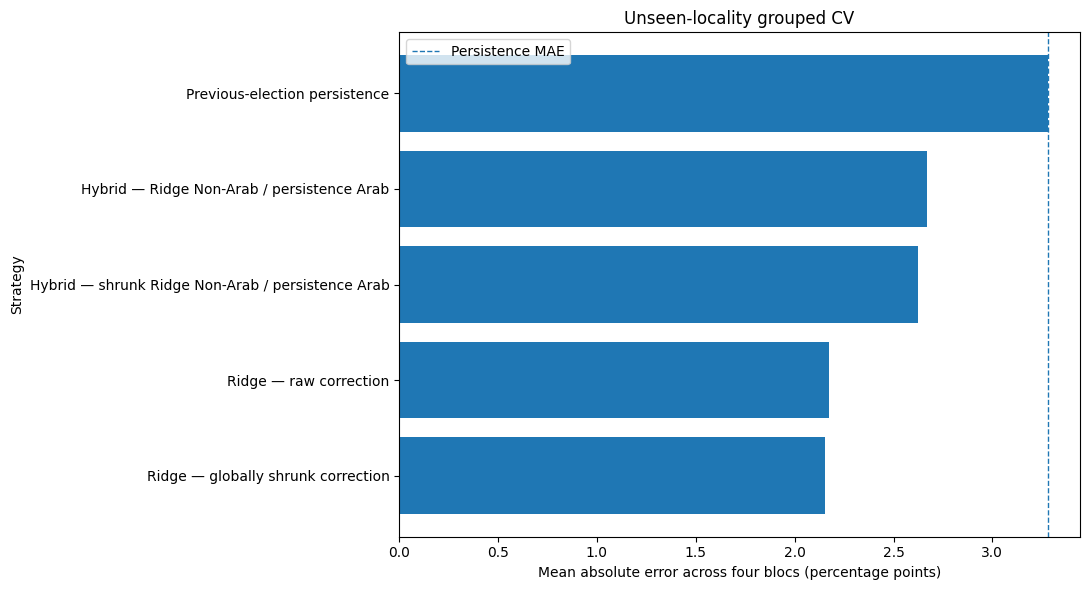

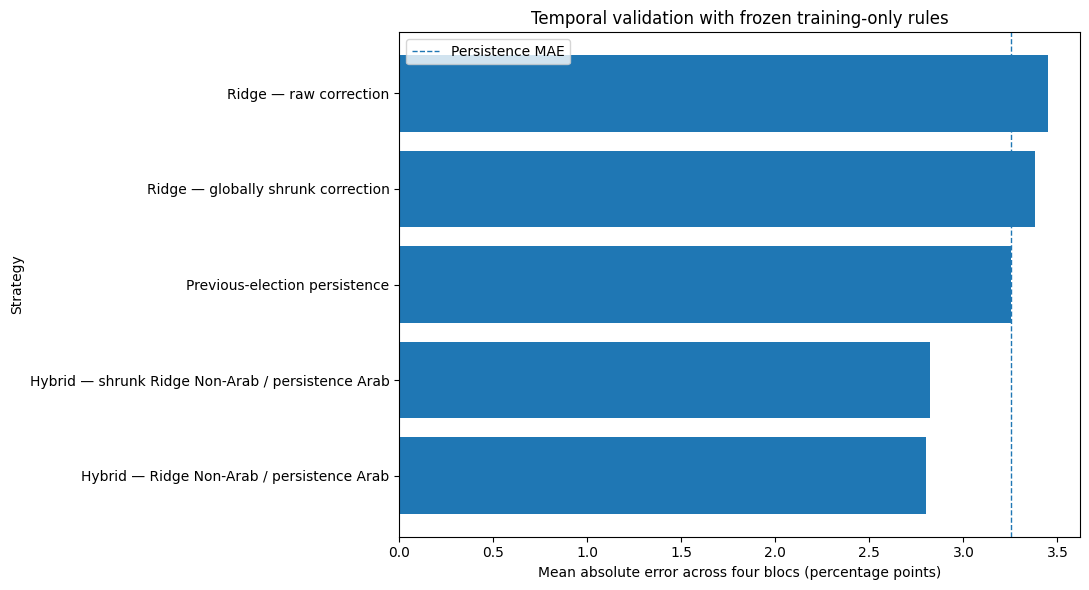

In [20]:

figure, axis = plt.subplots(
    figsize=(11, 6),
)

plot_data = (
    unseen_locality_cv_comparison
    .sort_values(
        "mae",
        ascending=True,
    )
)

axis.barh(
    plot_data[
        "strategy"
    ],
    plot_data[
        "mae"
    ],
)

axis.axvline(
    unseen_persistence_mae,
    linestyle="--",
    linewidth=1,
    label="Persistence MAE",
)

axis.set_title(
    "Unseen-locality grouped CV"
)
axis.set_xlabel(
    "Mean absolute error across four blocs "
    "(percentage points)"
)
axis.set_ylabel("Strategy")
axis.legend()

plt.tight_layout()

UNSEEN_CV_FIGURE_PATH = (
    FIGURES_DIR
    / "unseen_locality_cv_comparison.png"
)

plt.savefig(
    UNSEEN_CV_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


figure, axis = plt.subplots(
    figsize=(11, 6),
)

plot_data = (
    temporal_validation_strategy_comparison
    .sort_values(
        "mae",
        ascending=True,
    )
)

axis.barh(
    plot_data[
        "strategy"
    ],
    plot_data[
        "mae"
    ],
)

axis.axvline(
    temporal_persistence_mae,
    linestyle="--",
    linewidth=1,
    label="Persistence MAE",
)

axis.set_title(
    "Temporal validation with frozen training-only rules"
)
axis.set_xlabel(
    "Mean absolute error across four blocs "
    "(percentage points)"
)
axis.set_ylabel("Strategy")
axis.legend()

plt.tight_layout()

TEMPORAL_VALIDATION_FIGURE_PATH = (
    FIGURES_DIR
    / "temporal_validation_hybrid_comparison.png"
)

plt.savefig(
    TEMPORAL_VALIDATION_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## 14. Save outputs

In [21]:

TRAINING_SHRINKAGE_PATH = (
    TABLES_DIR
    / "training_oof_shrinkage_selection.csv"
)

TRAINING_STRATEGY_PATH = (
    TABLES_DIR
    / "training_oof_strategy_comparison.csv"
)

TRAINING_GROUP_PATH = (
    TABLES_DIR
    / "training_oof_strategy_by_group.csv"
)

TRAINING_BLOC_PATH = (
    TABLES_DIR
    / "training_oof_strategy_by_bloc.csv"
)

TRAINING_FOLD_AUDIT_PATH = (
    TABLES_DIR
    / "training_oof_fold_audit.csv"
)

UNSEEN_COMPARISON_PATH = (
    TABLES_DIR
    / "unseen_locality_cv_comparison.csv"
)

UNSEEN_GROUP_PATH = (
    TABLES_DIR
    / "unseen_locality_cv_by_group.csv"
)

UNSEEN_BLOC_PATH = (
    TABLES_DIR
    / "unseen_locality_cv_by_bloc.csv"
)

UNSEEN_FOLD_AUDIT_PATH = (
    TABLES_DIR
    / "unseen_locality_cv_fold_audit.csv"
)

TEMPORAL_COMPARISON_PATH = (
    TABLES_DIR
    / "temporal_validation_strategy_comparison.csv"
)

TEMPORAL_GROUP_PATH = (
    TABLES_DIR
    / "temporal_validation_by_group.csv"
)

TEMPORAL_BLOC_PATH = (
    TABLES_DIR
    / "temporal_validation_by_bloc.csv"
)

TEMPORAL_FEATURE_AUDIT_PATH = (
    TABLES_DIR
    / "temporal_validation_feature_filter_audit.csv"
)

CANDIDATE_ELIGIBILITY_PATH = (
    TABLES_DIR
    / "final_candidate_eligibility.csv"
)

UNSEEN_PREDICTIONS_PATH = (
    PROCESSED_DIR
    / "unseen_locality_oof_predictions.csv"
)

TEMPORAL_PREDICTIONS_PATH = (
    PROCESSED_DIR
    / "temporal_validation_hybrid_predictions.csv"
)

FROZEN_CANDIDATE_PATH = (
    SUMMARIES_DIR
    / "final_candidate_before_test.json"
)

NOTEBOOK_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_06_summary.json"
)

training_oof_shrinkage_selection.to_csv(
    TRAINING_SHRINKAGE_PATH,
    index=False,
    encoding="utf-8-sig",
)

training_oof_strategy_comparison.to_csv(
    TRAINING_STRATEGY_PATH,
    index=False,
    encoding="utf-8-sig",
)

training_oof_by_group.to_csv(
    TRAINING_GROUP_PATH,
    index=False,
    encoding="utf-8-sig",
)

training_oof_by_bloc.to_csv(
    TRAINING_BLOC_PATH,
    index=False,
    encoding="utf-8-sig",
)

training_oof_fold_audit.to_csv(
    TRAINING_FOLD_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

unseen_locality_cv_comparison.to_csv(
    UNSEEN_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)

unseen_locality_cv_by_group.to_csv(
    UNSEEN_GROUP_PATH,
    index=False,
    encoding="utf-8-sig",
)

unseen_locality_cv_by_bloc.to_csv(
    UNSEEN_BLOC_PATH,
    index=False,
    encoding="utf-8-sig",
)

development_oof_fold_audit.to_csv(
    UNSEEN_FOLD_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

temporal_validation_strategy_comparison.to_csv(
    TEMPORAL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)

temporal_validation_by_group.to_csv(
    TEMPORAL_GROUP_PATH,
    index=False,
    encoding="utf-8-sig",
)

temporal_validation_by_bloc.to_csv(
    TEMPORAL_BLOC_PATH,
    index=False,
    encoding="utf-8-sig",
)

temporal_feature_filter_audit.to_csv(
    TEMPORAL_FEATURE_AUDIT_PATH,
    index=False,
    encoding="utf-8-sig",
)

candidate_eligibility.to_csv(
    CANDIDATE_ELIGIBILITY_PATH,
    index=False,
    encoding="utf-8-sig",
)

unseen_locality_oof_predictions.to_csv(
    UNSEEN_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

temporal_validation_hybrid_predictions.to_csv(
    TEMPORAL_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

frozen_candidate_summary = {
    "frozen_candidate": (
        frozen_candidate
    ),
    "reason": (
        frozen_candidate_reason
    ),
    "selected_ridge_architecture": (
        selected_model_name
    ),
    "fixed_ridge_alpha": (
        selected_alpha
    ),
    "selected_global_shrinkage_lambda": (
        best_global_lambda
    ),
    "selected_non_arab_shrinkage_lambda": (
        best_non_arab_lambda
    ),
    "hybrid_direction_supported_by_training_oof": (
        hybrid_direction_supported
    ),
    "candidate_selection_rule": (
        "A non-persistence strategy must beat persistence "
        "on primary MAE in both development-period unseen-"
        "locality GroupKFold and temporal K23_to_K24 "
        "validation. Hybrid strategies are eligible only "
        "when the routing direction is supported by "
        "training-transition OOF results."
    ),
    "final_test_status": (
        "K24_to_K25 remains locked and unevaluated."
    ),
}

with FROZEN_CANDIDATE_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        frozen_candidate_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

notebook_summary = {
    "notebook": "06_unseen_localities",
    "development_sample": {
        "rows": int(
            len(development_data)
        ),
        "unique_localities": int(
            development_data[
                "locality_symbol"
            ].nunique()
        ),
        "transitions": sorted(
            development_data[
                "transition_id"
            ].unique().tolist()
        ),
    },
    "selected_model_from_notebook_05": {
        "name": (
            selected_model_name
        ),
        "alpha": (
            selected_alpha
        ),
    },
    "training_only_strategy_design": {
        "global_lambda": (
            best_global_lambda
        ),
        "non_arab_lambda": (
            best_non_arab_lambda
        ),
        "hybrid_direction_supported": (
            hybrid_direction_supported
        ),
    },
    "unseen_locality_cv": (
        unseen_locality_cv_comparison
        .to_dict(
            orient="records"
        )
    ),
    "temporal_validation": (
        temporal_validation_strategy_comparison
        .to_dict(
            orient="records"
        )
    ),
    "frozen_candidate": (
        frozen_candidate_summary
    ),
    "outputs": {
        "training_shrinkage": str(
            TRAINING_SHRINKAGE_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "unseen_comparison": str(
            UNSEEN_COMPARISON_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "unseen_predictions": str(
            UNSEEN_PREDICTIONS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "temporal_comparison": str(
            TEMPORAL_COMPARISON_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "temporal_predictions": str(
            TEMPORAL_PREDICTIONS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "frozen_candidate": str(
            FROZEN_CANDIDATE_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "unseen_figure": str(
            UNSEEN_CV_FIGURE_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "temporal_figure": str(
            TEMPORAL_VALIDATION_FIGURE_PATH.relative_to(
                REPO_ROOT
            )
        ),
    },
}

with NOTEBOOK_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        notebook_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved:")
for path in [
    TRAINING_SHRINKAGE_PATH,
    TRAINING_STRATEGY_PATH,
    TRAINING_GROUP_PATH,
    TRAINING_BLOC_PATH,
    TRAINING_FOLD_AUDIT_PATH,
    UNSEEN_COMPARISON_PATH,
    UNSEEN_GROUP_PATH,
    UNSEEN_BLOC_PATH,
    UNSEEN_FOLD_AUDIT_PATH,
    TEMPORAL_COMPARISON_PATH,
    TEMPORAL_GROUP_PATH,
    TEMPORAL_BLOC_PATH,
    TEMPORAL_FEATURE_AUDIT_PATH,
    CANDIDATE_ELIGIBILITY_PATH,
    UNSEEN_PREDICTIONS_PATH,
    TEMPORAL_PREDICTIONS_PATH,
    UNSEEN_CV_FIGURE_PATH,
    TEMPORAL_VALIDATION_FIGURE_PATH,
    FROZEN_CANDIDATE_PATH,
    NOTEBOOK_SUMMARY_PATH,
]:
    print("-", path)


Saved:
- /content/Election_Bloc_Prediction_Project/reports/tables/training_oof_shrinkage_selection.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/training_oof_strategy_comparison.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/training_oof_strategy_by_group.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/training_oof_strategy_by_bloc.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/training_oof_fold_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/unseen_locality_cv_comparison.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/unseen_locality_cv_by_group.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/unseen_locality_cv_by_bloc.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/unseen_locality_cv_fold_audit.csv
- /content/Election_Bloc_Prediction_Project/reports/tables/temporal_validation_strategy_comparison.csv
- /content/Election_Bloc_Prediction_Project/reports/table

## 15. Final quality checks

In [22]:

quality_checks = {
    "training_oof_rows": int(
        len(training_oof_delta)
    ),
    "development_oof_rows": int(
        len(development_oof_delta)
    ),
    "training_fold_locality_overlap_total": int(
        training_oof_fold_audit[
            "locality_overlap"
        ].sum()
    ),
    "development_fold_locality_overlap_total": int(
        development_oof_fold_audit[
            "locality_overlap"
        ].sum()
    ),
    "selected_global_lambda_between_0_and_1": bool(
        0
        <= best_global_lambda
        <= 1
    ),
    "selected_non_arab_lambda_between_0_and_1": bool(
        0
        <= best_non_arab_lambda
        <= 1
    ),
    "final_test_rows_loaded_only_as_locked_metadata": int(
        len(final_test_locked)
    ),
    "final_candidate_saved": (
        FROZEN_CANDIDATE_PATH.exists()
    ),
    "maximum_unseen_strategy_sum_error": float(
        max(
            np.abs(
                predictions.sum(
                    axis=1
                )
                - 100
            ).max()
            for predictions
            in development_strategy_predictions.values()
        )
    ),
    "maximum_temporal_strategy_sum_error": float(
        max(
            np.abs(
                predictions.sum(
                    axis=1
                )
                - 100
            ).max()
            for predictions
            in temporal_strategy_predictions.values()
        )
    ),
}

if (
    quality_checks[
        "training_fold_locality_overlap_total"
    ]
    != 0
):
    raise ValueError(
        "Training OOF contains locality leakage."
    )

if (
    quality_checks[
        "development_fold_locality_overlap_total"
    ]
    != 0
):
    raise ValueError(
        "Development grouped CV contains locality leakage."
    )

if (
    quality_checks[
        "maximum_unseen_strategy_sum_error"
    ]
    > 1e-6
):
    raise ValueError(
        "An unseen-locality strategy does not sum to 100."
    )

if (
    quality_checks[
        "maximum_temporal_strategy_sum_error"
    ]
    > 1e-6
):
    raise ValueError(
        "A temporal-validation strategy does not sum to 100."
    )

print("All Notebook 06 quality checks passed.")
pd.Series(
    quality_checks,
    dtype="object",
)


All Notebook 06 quality checks passed.


,0
training_oof_rows,449
development_oof_rows,673
training_fold_locality_overlap_total,0
development_fold_locality_overlap_total,0
selected_global_lambda_between_0_and_1,True
selected_non_arab_lambda_between_0_and_1,True
final_test_rows_loaded_only_as_locked_metadata,1213
final_candidate_saved,True
maximum_unseen_strategy_sum_error,0.0
maximum_temporal_strategy_sum_error,0.0



## Notebook 06 completion checklist

This notebook is complete when:

- Notebook 05's selected Ridge architecture and alpha load successfully.
- K24→K25 remains locked.
- Shrinkage values are selected using training-transition grouped OOF only.
- Every grouped fold has zero locality overlap.
- Raw Ridge, shrunk Ridge and hybrid strategies are compared.
- Results are reported overall, by bloc and by Arab/non-Arab group.
- The same frozen rules are evaluated on temporal validation.
- Hybrid eligibility is linked to training-only OOF support.
- A final candidate is frozen before the final test.
- All prediction tables, audits, figures and summaries are saved.

The next notebook is:

> `07_explainability_and_anomalies.ipynb`

It will explain the selected learned component, identify localities where it improves or harms persistence, examine influential variables, and separate genuine voting-change anomalies from model failure.
